# Aula 6 — E quando ninguém escreveu a resposta?

**Disciplina 2 · Aprendizado de Máquina · IASEG**

Até aqui, todo modelo aprendeu com uma coluna que alguém preencheu: `y` (o preço, a espécie, sobreviveu ou não, comprou ou não).
Hoje essa coluna não existe. A pergunta muda de *"qual é a resposta deste caso?"* para *"que grupos existem aqui dentro?"*

- **Parte 1** — Iris sem a espécie: o k-means
- **Parte 2** — Quantos grupos?
- **Parte 3** — Arrombamentos em Chicago: duas perguntas, dois mapas
- **Parte 4** — Drogas: a mesma receita, outro mapa
- **Extra** — O ciclo

## Configuração

`pandas` para os dados, `numpy` para as contas, `matplotlib` para os gráficos. O resto é importado na etapa em que for usado.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

---

# Parte 1 — Iris sem a espécie

## Etapa 1 — Os dados, e a coluna que vamos esconder

As mesmas 150 flores da Aula 1, com as quatro medidas em cm. A espécie fica **guardada numa variável à parte**:
o modelo nunca vai ver essa coluna. Só vamos usá-la no fim, para conferir.

*(Num problema de agrupamento de verdade, essa coluna não existe. Aqui ela existe porque nós a escondemos, e isso permite um teste que a vida real não permite.)*

In [3]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)

# As quatro medidas (em cm): é só isso que o modelo vai ver
X = iris.data.copy()
X.columns = ['sepala_comp', 'sepala_larg', 'petala_comp', 'petala_larg']

# A espécie, guardada à parte: o modelo NUNCA vê esta coluna
especie = iris.target.map(dict(enumerate(iris.target_names)))

print('Flores:', len(X))
X.head()

Flores: 150


,sepala_comp,sepala_larg,petala_comp,petala_larg
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Etapa 2 — O k-means com k = 3

O k-means faz duas coisas, e repete até nada mudar (o exercício do quadro):

1. cada flor vai para o **centro mais perto**;
2. cada centro vai para a **média** das suas flores.

- `n_clusters=3`: quantos grupos (o *k*). **Quem escolhe é você**, não o método.
- `n_init=10`: um começo ruim pode terminar num lugar ruim; o k-means começa 10 vezes e fica com o melhor.
- `random_state=42`: fixa os sorteios dos começos, para todo mundo ter o mesmo resultado (qualquer número serviria).

In [4]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)

# fit_predict: aprende os centros e devolve o grupo de cada flor
grupos = kmeans.fit_predict(X)

pd.Series(grupos).value_counts().sort_index()

0    40
1    50
2    28
3    32
Name: count, dtype: int64

Os grupos vêm como **0, 1, 2**. Sem nome. O que o k-means guardou de cada grupo é só o **centro**: uma "flor média".
Leiam a tabela como um retrato de cada grupo.

In [5]:
centros = pd.DataFrame(kmeans.cluster_centers_, columns=X.columns).round(2)
centros.index.name = 'grupo'
centros

,sepala_comp,sepala_larg,petala_comp,petala_larg
grupo,,,,
0,6.25,2.86,4.82,1.62
1,5.01,3.43,1.46,0.25
2,5.53,2.64,3.96,1.23
3,6.91,3.10,5.85,2.13


**Deem um nome a cada grupo**, só olhando os centros (por exemplo: "pétala pequena", "pétala grande"...). Escrevam aqui:

- grupo 0: ...
- grupo 1: ...
- grupo 2: ...

Isso não é detalhe: **quem nomeia os grupos é você**. O método devolve números.

## Etapa 3 — O teste que a vida real não deixa fazer

Agora, e só agora, a coluna escondida. **Antes de rodar:** os três grupos vão bater com as três espécies? Todos, alguns, nenhum?

Cruzem os grupos com as espécies numa tabela (Aula 3: `03_Avaliacao…`, a tabela de contagens com `pd.crosstab`).

In [6]:
# Uma linha por grupo, uma coluna por espécie
pd.crosstab(grupos, especie, rownames=['grupo'], colnames=['espécie'])

espécie,setosa,versicolor,virginica
grupo,,,
0,0,23,17
1,50,0,0
2,0,27,1
3,0,0,32


Um grupo tem as **50 setosas e nada mais**. Os outros dois misturam versicolor e virginica: 134 das 150 flores
caem num grupo dominado pela própria espécie.

O k-means **não redescobriu as espécies**. Ele achou regiões de flores parecidas, e a setosa é tão diferente
que ficou sozinha. Versicolor e virginica se sobrepõem nas medidas, e nenhum método sem rótulo separa isso limpo.

## Etapa 4 — Uma flor nova

O k-means responde um caso novo de um jeito só: **o centro mais perto**. Não olha as 150 flores (como o kNN faria), só os três centros.

In [7]:
nova_flor = pd.DataFrame([[6.0, 3.0, 4.8, 1.8]], columns=X.columns)

# A distância da flor nova até cada centro
distancias = np.linalg.norm(kmeans.cluster_centers_ - nova_flor.values, axis=1)
print('Distância a cada centro:', distancias.round(2))
print('Grupo da flor nova:', kmeans.predict(nova_flor)[0])

Distância a cada centro: [0.34 3.84 1.18 1.43]
Grupo da flor nova: 0


---

# Parte 2 — Quantos grupos?

## Etapa 5 — E com k = 2?

**Antes de rodar:** se o k-means só puder fazer **dois** grupos, que espécies vão ficar juntas?

In [8]:
kmeans2 = KMeans(n_clusters=2, n_init=10, random_state=42)   # dois grupos
grupos2 = kmeans2.fit_predict(X)

pd.crosstab(grupos2, especie, rownames=['grupo'], colnames=['espécie'])

espécie,setosa,versicolor,virginica
grupo,,,
0,0,47,50
1,50,3,0


Quais espécies ficaram juntas? Olhando só as medidas, faz sentido?

Com dois grupos, a divisão também é "certa": ela responde outra pergunta (*setosa ou não?*).
**Nenhum k é o certo em si; cada k responde uma pergunta.**

## Etapa 6 — A distância total

Para cada k, o k-means informa a **distância total** dos pontos aos seus centros (`inertia_`): quanto menor, mais "apertados" os grupos.

**Antes de rodar:** quando o k aumenta, essa distância sobe, desce, ou depende?

In [19]:
linhas = []
for k in range(1, 9):
    m = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    linhas.append({'k': k, 'distância total': round(m.inertia_, 1)})

tabela_k = pd.DataFrame(linhas).set_index('k')
tabela_k

,distância total
k,
1,681.4
2,152.3
3,78.9
4,57.2
5,46.5
6,39.0
7,34.3
8,30.1


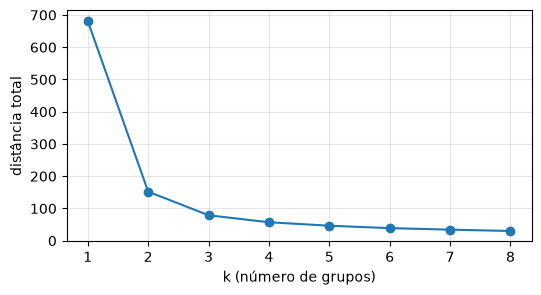

In [10]:
plt.figure(figsize=(6, 3))
plt.plot(tabela_k.index, tabela_k['distância total'], marker='o')
plt.xlabel('k (número de grupos)')
plt.ylabel('distância total')
plt.grid(alpha=0.3)
plt.show()

**Ela sempre cai.** Com mais grupos, cada ponto fica mais perto de algum centro; com k = 150, a distância seria zero
(cada flor no seu próprio grupo).

Vocês já viram isso: a **nota do treino** na curva da Aula 4 também só melhorava com mais profundidade.
A diferença é que ali existia um teste para dizer quando parar. **Aqui não existe teste nenhum.**

- **O cotovelo:** onde a queda para de valer a pena. Onde vocês poriam o cotovelo neste gráfico, e por quê?
- É um julgamento, não uma leitura. Quem decide o k é **o uso**: que pergunta o agrupamento precisa responder?

---

# Parte 3 — Arrombamentos em Chicago

## Etapa 7 — Os dados

Registros públicos da polícia de Chicago, **2024**, um tipo só: *burglary* (**arrombamento**: entrar num imóvel para furtar).
Cada linha é um registro, com o local aproximado (a quadra), a data e se houve prisão.

Dados públicos, sem nome de ninguém: a regra da LGPD do primeiro dia continua valendo.

In [92]:
URL_ARROMBAMENTO = "https://raw.githubusercontent.com/mateuslevisf/dados-iaseg/refs/heads/main/chicago_2024_burglary.csv"

arrombamentos = pd.read_csv(URL_ARROMBAMENTO)

print('Registros:', len(arrombamentos))
arrombamentos.head()

Registros: 8437


,id,date,primary_type,description,location_description,arrest,domestic,district,community_area,latitude,longitude
0,13707815,2024-12-31T22:00:00.000,BURGLARY,UNLAWFUL ENTRY,RESIDENCE - GARAGE,False,False,5,49,41.697454,-87.611056
1,13709623,2024-12-31T21:00:00.000,BURGLARY,FORCIBLE ENTRY,RESIDENCE,False,False,8,62,41.789709,-87.714375
2,13709190,2024-12-31T21:00:00.000,BURGLARY,FORCIBLE ENTRY,SMALL RETAIL STORE,False,False,9,61,41.807871,-87.664954
3,13707901,2024-12-31T17:30:00.000,BURGLARY,UNLAWFUL ENTRY,RESIDENCE,False,False,8,56,41.803445,-87.744266
4,13710467,2024-12-31T17:00:00.000,BURGLARY,UNLAWFUL ENTRY,RESIDENCE - GARAGE,False,False,25,20,41.918953,-87.729879


## Etapa 8 — De graus para quilômetros

Latitude e longitude são graus, e um grau de longitude não mede o mesmo que um grau de latitude.
A célula abaixo converte tudo para **quilômetros**, para a distância fazer sentido. **Não precisa entender esta célula.**

Ela também tira os registros sem local (poucos) e define uma função para desenhar os mapas.

Registros com local: 8397


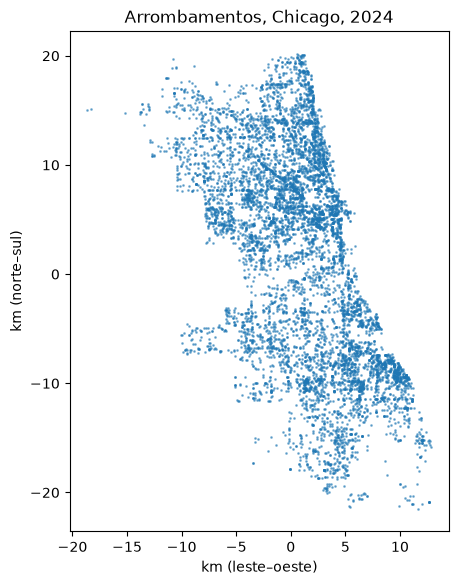

In [12]:
# Graus → km, com a origem no centro de Chicago (não precisa entender)
LAT0, LON0 = 41.84, -87.68
def em_km(d):
    x = (d['longitude'] - LON0) * 111.32 * np.cos(np.radians(LAT0))
    y = (d['latitude'] - LAT0) * 110.57
    return np.column_stack([x, y])

CORES = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']

def cores_dos_grupos(X_km, grupos, perto=2.5):
    """Uma cor por grupo; grupos a menos de `perto` km um do outro nunca repetem a cor."""
    from scipy.spatial import cKDTree
    ids = sorted(set(grupos) - {-1}, key=lambda g: -(grupos == g).sum())
    if len(ids) <= len(CORES):
        return {g: CORES[i] for i, g in enumerate(ids)}
    arvores = {g: cKDTree(X_km[grupos == g]) for g in ids}
    cor = {}
    for g in ids:
        usadas = {cor[h] for h in cor if arvores[g].sparse_distance_matrix(arvores[h], perto).nnz > 0}
        livres = [c for c in CORES if c not in usadas]
        cor[g] = livres[0] if livres else CORES[len(cor) % len(CORES)]
    return cor

def desenha_mapa(X_km, grupos=None, titulo=''):
    """Pontos no mapa. Com grupos do DBSCAN: ruído em cinza, cada grupo com a sua cor. Com grupos do k-means: uma cor por grupo."""
    plt.figure(figsize=(5, 6.5))
    if grupos is None:
        plt.scatter(X_km[:, 0], X_km[:, 1], s=1, alpha=0.5)
    elif (grupos == -1).any():
        ruido = grupos == -1
        cor = cores_dos_grupos(X_km, grupos)
        plt.scatter(X_km[ruido, 0], X_km[ruido, 1], s=1, color='lightgray')
        plt.scatter(X_km[~ruido, 0], X_km[~ruido, 1], s=2, c=[cor[g] for g in grupos[~ruido]])
    else:
        plt.scatter(X_km[:, 0], X_km[:, 1], s=1, c=grupos, cmap='tab10')
    plt.gca().set_aspect('equal')
    plt.xlabel('km (leste–oeste)'); plt.ylabel('km (norte–sul)')
    plt.title(titulo)
    plt.show()

# Só os registros com local
arrombamentos = arrombamentos.dropna(subset=['latitude', 'longitude']).reset_index(drop=True)
X_arromb = em_km(arrombamentos)

print('Registros com local:', len(arrombamentos))
desenha_mapa(X_arromb, titulo='Arrombamentos, Chicago, 2024')

## Etapa 9 — Primeira pergunta: "divida a cidade em 8 setores"

O k-means com k = 8. Cada setor fica com os arrombamentos mais perto do seu centro.

Arrombamentos por setor: [1586, 1513, 1170, 1095, 867, 839, 698, 629]


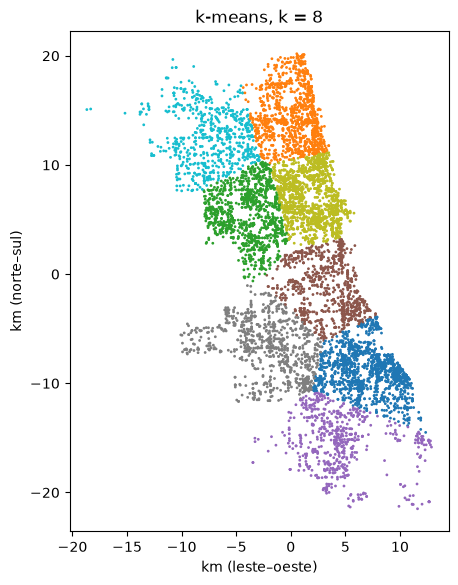

In [84]:
kmeans8 = KMeans(n_clusters=8, n_init=10, random_state=42)
setores = kmeans8.fit_predict(X_arromb)

print('Arrombamentos por setor:', sorted(pd.Series(setores).value_counts().tolist(), reverse=True))
desenha_mapa(X_arromb, setores, titulo='k-means, k = 8')

Oito setores, **todos com centenas de arrombamentos**, cobrindo a cidade inteira. O k-means sempre faz isso:
todo ponto ganha um grupo, e o número de grupos é o que vocês pediram. É a resposta certa para *"divida em 8"*.
Não é a resposta para *"onde está cheio?"*.

## Etapa 10 — Segunda pergunta: "onde está cheio?"

O **DBSCAN** (o exercício da folha). Dois ajustes:

- `eps`: o **raio**, aqui em km. Dois registros a menos que isso são vizinhos.
- `min_samples`: quantos vizinhos (contando o próprio) fazem um lugar **cheio**.

Pontos cheios que se alcançam formam um grupo. Quem não está em lugar cheio nem perto de um é **ruído**: o grupo `-1`.

Grupos: 33
Ruído: 62% dos arrombamentos


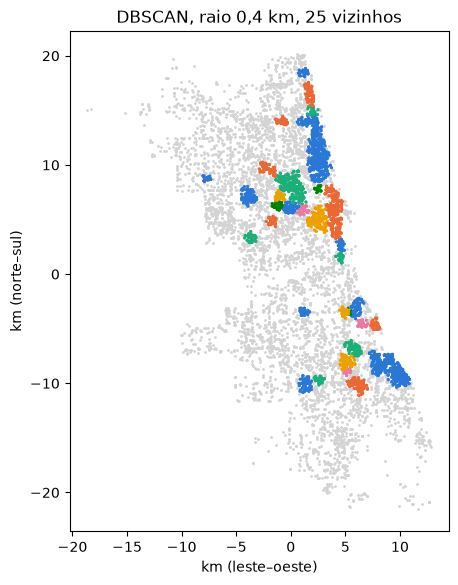

In [14]:
from sklearn.cluster import DBSCAN

# raio de 400 m, e pelo menos 25 registros dentro dele
dbscan = DBSCAN(eps=0.4, min_samples=25)
grupos_db = dbscan.fit_predict(X_arromb)

n_grupos = grupos_db.max() + 1          # os grupos são 0, 1, 2...; o -1 é ruído
parte_ruido = (grupos_db == -1).mean()

print('Grupos:', n_grupos)
print(f'Ruído: {parte_ruido:.0%} dos arrombamentos')
desenha_mapa(X_arromb, grupos_db, titulo='DBSCAN, raio 0,4 km, 25 vizinhos')

33 lugares cheios, e **62% dos arrombamentos em grupo nenhum**.

Isso não quer dizer que esses 62% "não contam": são arrombamentos que aconteceram **fora de qualquer lugar cheio**.
Um mapa de hotspots, sozinho, esconde a maior parte do problema.

## Etapa 11 — O raio decide

**Antes de rodar:** com um raio **maior**, vai ter mais ruído ou menos? Mais grupos ou menos?

Escolham um raio (em km) e rodem. Depois tentem outro. Anotem para o quadro: raio, grupos, ruído.

Raio 0.7 km: 13 grupos, ruído 14%


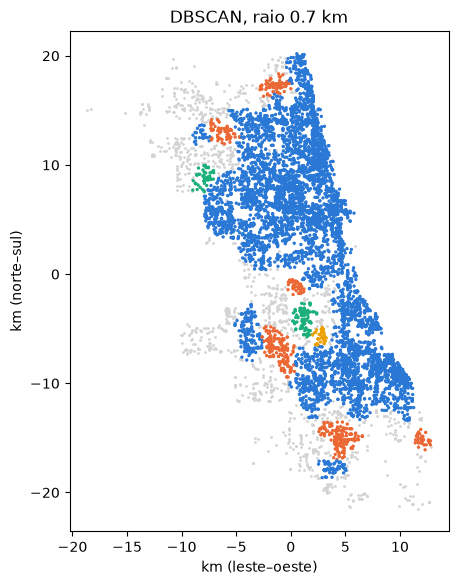

In [87]:
meu_raio = 0.7     # em km: experimentem, por exemplo, entre 0.2 e 1

grupos_meu = DBSCAN(eps=meu_raio, min_samples=25).fit_predict(X_arromb)

print(f'Raio {meu_raio} km: {grupos_meu.max() + 1} grupos, ruído {(grupos_meu == -1).mean():.0%}')
desenha_mapa(X_arromb, grupos_meu, titulo=f'DBSCAN, raio {meu_raio} km')

Raio pequeno: quase tudo vira ruído. Raio grande: tudo vira um grupo só, e o "hotspot" passa a ser a cidade.

**Quem escolhe o raio escolhe o hotspot.** Um mapa de hotspots tem que vir com os ajustes que o produziram.

---

# Parte 4 — Drogas: a mesma receita

## Etapa 12 — Outro tipo de registro

Os registros de **drogas** (*narcotics*) de Chicago em 2024, com **os mesmos ajustes**: raio de 0,4 km, 25 vizinhos.

**Antes de rodar:** desenhem no papel onde vocês acham que vai estar a mancha. Parecida com a dos arrombamentos?

Registros com local: 5957
Grupos: 12 | ruído: 40%
O maior grupo tem 2774 registros: 47% do ano inteiro


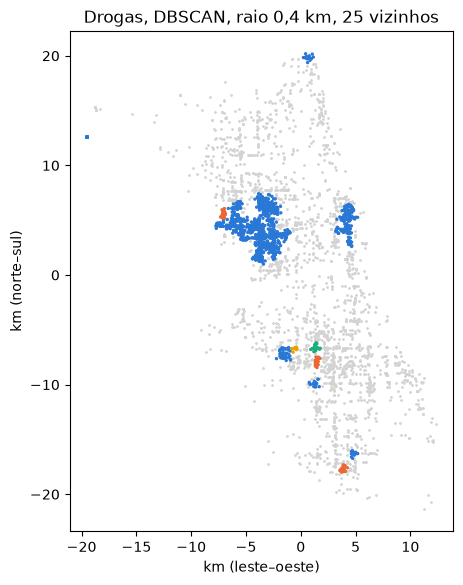

In [88]:
URL_DROGAS = "https://raw.githubusercontent.com/mateuslevisf/dados-iaseg/refs/heads/main/chicago_2024_narcotics.csv"

drogas = pd.read_csv(URL_DROGAS).dropna(subset=['latitude', 'longitude']).reset_index(drop=True)
X_drogas = em_km(drogas)

grupos_drogas = DBSCAN(eps=0.4, min_samples=25).fit_predict(X_drogas)

tamanhos = pd.Series(grupos_drogas[grupos_drogas >= 0]).value_counts()
print('Registros com local:', len(drogas))
print('Grupos:', grupos_drogas.max() + 1, f'| ruído: {(grupos_drogas == -1).mean():.0%}')
print(f'O maior grupo tem {tamanhos.max()} registros: {tamanhos.max() / len(drogas):.0%} do ano inteiro')
desenha_mapa(X_drogas, grupos_drogas, titulo='Drogas, DBSCAN, raio 0,4 km, 25 vizinhos')

Um único grupo com quase metade dos registros do ano. Os arrombamentos se espalham pela cidade; os registros de drogas se concentram.

Isso quer dizer que o uso de drogas em Chicago está quase todo ali?

## Etapa 13 — Como nasce cada registro

Um registro são duas coisas: **algo aconteceu**, e **alguém registrou**. A coluna `arrest` diz se o registro terminou em prisão.

Calculem a proporção de registros com prisão nos dois tipos (Aula 2: `02_Auditoria…`, a taxa de base com `value_counts(normalize=True)`).

In [89]:
print('Arrombamento:')
print(arrombamentos['arrest'].value_counts(normalize=True).round(3))
print()
print('Drogas:')
print(drogas['arrest'].value_counts(normalize=True).round(3))

Arrombamento:
arrest
False    0.945
True     0.055
Name: proportion, dtype: float64

Drogas:
arrest
True     0.964
False    0.036
Name: proportion, dtype: float64


In [ ]:
# Onde cada tipo de registro acontece
print('Arrombamento:', arrombamentos['location_description'].value_counts().head(4).to_dict())
print('Drogas:      ', drogas['location_description'].value_counts().head(4).to_dict())

- **Arrombamento:** de cada 100 registros, uns 6 com prisão. Acontece em apartamentos e casas. **A vítima chega em casa, vê a porta arrombada e chama a polícia.**
- **Drogas:** de cada 100 registros, uns 96 com prisão. Acontece na rua, na calçada, no beco. **O registro só existe porque a polícia parou alguém.**

Então o mapa de drogas mostra, sobretudo, **onde a polícia estava olhando**. Não mostra onde as drogas estão.

A pergunta para qualquer mapa de hotspots: **quem gera esse registro?**

---

# Extra — O ciclo

Duas áreas com **exatamente o mesmo crime de verdade** (em média 10 por dia cada). Onde a viatura está, 90% do que acontece vira registro;
onde ela não está, 30%. Todo dia a viatura vai para a área com **mais registros até agora**.

Um brinquedo, não um modelo da realidade: **as suposições são a lição.** Mudem `onde_esta` e `onde_nao_esta` e rodem de novo.
O que acontece se os dois forem iguais?

In [ ]:
onde_esta = 0.9       # chance de virar registro onde a viatura está
onde_nao_esta = 0.3   # chance de virar registro onde ela não está

rng = np.random.default_rng(42)
registros = np.array([0, 0])
for dia in range(200):
    # a viatura vai para a área com mais registros (empate: sorteio)
    viatura = rng.integers(2) if registros[0] == registros[1] else registros.argmax()
    for area in (0, 1):
        crimes = rng.poisson(10)                                  # o crime de verdade: igual nas duas
        chance = onde_esta if area == viatura else onde_nao_esta
        registros[area] += rng.binomial(crimes, chance)           # o que vira registro

print('Registros em cada área depois de 200 dias:', registros)
print(f'A área que lidera ficou com {registros.max() / registros.sum():.0%} dos registros')

O crime é igual nas duas áreas, e os registros não. **O mapa confirma a si mesmo**: mais viatura → mais registro → mais viatura.

---

# Fechando

| | k-means | DBSCAN |
|---|---|---|
| **A pergunta** | Divida em k grupos | Onde está cheio? |
| **Vocês escolhem** | k | o raio (`eps`) e o mínimo de vizinhos (`min_samples`) |
| **Todo ponto ganha grupo?** | Sim | Não: o que sobra é ruído (`-1`) |
| **Forma dos grupos** | Em volta de um centro | Qualquer forma |
| **Caso novo** | O centro mais perto (`predict`) | Não responde direto: roda de novo |

Sem a coluna de resposta, nada substitui a acurácia. Quem julga o agrupamento é **você**: lendo os grupos, cruzando com o que já sabe,
e perguntando que decisão ele alimenta.

**Para pensar (pergunta 12 do banco):** completem, sobre o mapa de drogas: *"este mapa não deve ser usado para ______."*